# <center>Generalized Method of Moments</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Define the GMM estimator as the minimizer of a quadratic form in sample moments, $\hat\theta_I(W) = \arg\min_\theta \bar g_I(\theta)^\top W \bar g_I(\theta)$, and recognize the method of moments and 2SLS as special cases.

* Derive consistency and asymptotic normality of GMM using LLN/CMT/CLT/Slutsky, and identify $V(W) = (G^\top W G)^{-1} G^\top W \Omega W G (G^\top W G)^{-1}$ as the asymptotic variance.

* Prove that $W^* = \Omega^{-1}$ is the *efficient* weight matrix in the sense of minimizing $V(W)$, and that the resulting variance is $(G^\top\Omega^{-1}G)^{-1}$.

* Implement two-step GMM from scratch, initial consistent step → estimate $\hat\Omega$ → efficient step, and confirm the efficiency gain over 2SLS in the heteroskedastic case.

* Carry out Hansen's $J$-test for over-identification, verify it numerically against the Sargan test on the Mroz returns-to-schooling regression, and contrast their inferential content.

* See OLS, IV, 2SLS, and MLE as instances of a single GMM template and recognize their asymptotic distributions as corollaries of the master theorem.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 13.

**[Han]** Hansen, L. P. (1982). 'Large Sample Properties of Generalized Method of Moments Estimators'. *Econometrica*, 50(4), 1029–1054.

**[CT]** Cameron, A. C., and Trivedi, P. K. (2005). *Microeconometrics: Methods and Applications*. Cambridge University Press. Chapter 6.

**[NM]** Newey, W. K., and McFadden, D. (1994). 'Large Sample Estimation and Hypothesis Testing'. In *Handbook of Econometrics*, vol. 4, ch. 36.

**[Im]** Imbens, G. W. (2002). 'Generalized Method of Moments and Empirical Likelihood'. *Journal of Business & Economic Statistics*, 20(4), 493–506.

# Motivation: moment conditions as the primitive

* All of the estimators developed so far, OLS, IV, 2SLS, MLE, share a common structure. Each is defined (or characterized in its first-order conditions) by a population moment condition $\mathbb{E}[g(z_i;\theta_0)] = 0$ at the true parameter $\theta_0$, and is implemented by setting the sample analog of that moment to zero, or by minimizing a norm of it when there are more moments than parameters.

* GMM (Hansen 1982) packages this observation as a general estimator. The starting point is no longer a likelihood or a regression equation, but a vector of moment conditions $g(z;\theta)\in\mathbb{R}^L$ with $L\geq K = \dim(\theta)$. The estimator is defined by minimizing a quadratic form, and the *choice of the quadratic form*, the weight matrix $W$, determines the efficiency of the estimator while not affecting its consistency.

* GMM is the right framework when the model offers natural moment conditions but no clean likelihood: Euler equations in consumption, orthogonality conditions in IV, conditional moment restrictions in macro and finance. We illustrate on a setting we know well, the Mroz returns to schooling instrumented by parents' education, where 2SLS turns out to be a non-efficient GMM, and the two-step efficient GMM delivers a (modest) efficiency gain.

## Loading our libraries and data

We continue with the Mroz (1987) sample of working women, and the same Mincer specification studied since Lecture 3: $\log\text{wage} = \beta_0 + \beta_{\text{educ}}\,\text{educ} + \beta_{\text{exper}}\,\text{exper} + \beta_{\text{exper}^2}\,\text{exper}^2 + \varepsilon$, with `educ` instrumented by mother's and father's education.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from types import SimpleNamespace
import linearmodels.iv as iv

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])
I = len(mroz_w)

y_i = mroz_w['lwage'].values
X_i_k = np.column_stack([
    np.ones(I),
    mroz_w['educ'].values,                       # endogenous regressor
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
Z_i_l = np.column_stack([
    np.ones(I),
    mroz_w['motheduc'].values,                   # instrument 1 (excluded)
    mroz_w['fatheduc'].values,                   # instrument 2 (excluded)
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
xnames = ['const', 'educ', 'exper', 'exper^2']
K, L = X_i_k.shape[1], Z_i_l.shape[1]
print(f'I = {I}, K = {K} (parameters), L = {L} (moments); over-identification = L - K = {L - K}')


I = 428, K = 4 (parameters), L = 5 (moments); over-identification = L - K = 1


# 1. Method of moments and GMM

## 1.1 Moment conditions

Let $\{z_i\}_{i=1}^I$ be i.i.d. observations and $g:\mathcal{Z}\times\Theta\to\mathbb{R}^L$ a known function with $\theta\in\Theta\subseteq\mathbb{R}^K$. Suppose the true parameter $\theta_0$ satisfies
$$
\mathbb{E}[g(z_i;\theta_0)] = 0_{L\times 1}.
$$
The sample analog is $\bar g_I(\theta) := I^{-1}\sum_i g(z_i;\theta)$.

## 1.2 The just-identified case ($L = K$): method of moments

When $L = K$, we typically can set $\bar g_I(\hat\theta) = 0$ exactly. The resulting estimator is the **method of moments (MM)** estimator. OLS is the canonical example: with $g_i(\beta) = x_i(y_i - x_i^\top\beta)$, the FOC $\bar g_I(\hat\beta) = 0$ is exactly the normal equations $X^\top y = X^\top X\hat\beta$.

## 1.3 The over-identified case ($L > K$): GMM

When $L > K$, the system $\bar g_I(\hat\theta) = 0$ has no exact solution: there are more equations than unknowns. The GMM estimator chooses $\hat\theta$ to make the sample moments *as small as possible* in a weighted Euclidean norm:
$$
\hat\theta_I(W) := \arg\min_{\theta\in\Theta}\;\bar g_I(\theta)^\top W\,\bar g_I(\theta),
$$
where $W$ is an $L\times L$ positive-definite weight matrix. Different choices of $W$ yield consistent estimators with different asymptotic variances; the *efficient* choice (§4) minimizes that variance.

# 2. Asymptotic theory of GMM

Define the population moment and its Jacobian, plus the score covariance:
$$
G := \mathbb{E}\bigl[\nabla_\theta g(z_i;\theta_0)\bigr]\in\mathbb{R}^{L\times K}, \qquad
\Omega := \mathbb{E}\bigl[g(z_i;\theta_0)\,g(z_i;\theta_0)^\top\bigr]\in\mathbb{R}^{L\times L}.
$$

## 2.1 Consistency

---

**Theorem.** Under standard regularity conditions (compact $\Theta$, identification: $\bar g_I(\theta)^\top W\bar g_I(\theta)$ uniquely minimized at $\theta_0$ in the limit, uniform LLN), $\hat\theta_I(W)\xrightarrow{p}\theta_0$ for every PD $W$.

---

## 2.2 Asymptotic normality

---

**Theorem.** Suppose, in addition to the conditions above, that $g$ is continuously differentiable, that $G$ has full column rank $K$, and that the CLT applies to $g(z_i;\theta_0)$. Then
$$
\sqrt{I}\bigl(\hat\theta_I(W) - \theta_0\bigr)\xrightarrow{d}\mathcal{N}\bigl(0,\,V(W)\bigr),
$$
$$
V(W) := (G^\top W G)^{-1}\,G^\top W\,\Omega\,W\,G\,(G^\top W G)^{-1}.
$$

---

**Proof.** The FOC of the GMM problem is $\bar G_I(\hat\theta_I)^\top W\bar g_I(\hat\theta_I) = 0$, where $\bar G_I(\theta) := \nabla_\theta\bar g_I(\theta)$. A first-order Taylor expansion of $\bar g_I$ around $\theta_0$:
$$
\bar g_I(\hat\theta_I) = \bar g_I(\theta_0) + \bar G_I(\tilde\theta_I)(\hat\theta_I - \theta_0).
$$
Multiplying the FOC and solving for $\sqrt{I}(\hat\theta_I - \theta_0)$:
$$
\sqrt I(\hat\theta_I - \theta_0) = -\bigl[\bar G_I(\hat\theta_I)^\top W\bar G_I(\tilde\theta_I)\bigr]^{-1}\bar G_I(\hat\theta_I)^\top W\sqrt I\,\bar g_I(\theta_0).
$$
By the LLN, $\bar G_I\xrightarrow{p}G$. By the CLT, $\sqrt I\,\bar g_I(\theta_0)\xrightarrow{d}\mathcal{N}(0,\Omega)$. Slutsky's theorem gives the result. $\square$

# 3. The efficient weight matrix

The asymptotic variance $V(W)$ depends on $W$. We may ask: among all positive-definite weight matrices, which one delivers the smallest $V(W)$? The answer is one of the central results of GMM theory.

---

**Theorem (Efficient GMM, Hansen 1982).** For every positive-definite $W$,
$$
V(W) \succeq V(\Omega^{-1}) = (G^\top\Omega^{-1} G)^{-1},
$$
with equality iff $W$ is proportional to $\Omega^{-1}$ on the row space of $G$. The matrix $W^* = \Omega^{-1}$ is the **efficient weight matrix**, and the GMM estimator $\hat\theta_I(W^*)$ is efficient within the class of GMM estimators based on the moment $g$.

---

**Proof sketch.** Write $M := \Omega^{1/2} W G (G^\top W G)^{-1}$ and $N := \Omega^{-1/2} G (G^\top \Omega^{-1} G)^{-1}$. Then $M^\top M = V(W)$, $N^\top N = V(\Omega^{-1})$, and $M^\top N = (G^\top W G)^{-1} G^\top W G\,(G^\top \Omega^{-1} G)^{-1} = V(\Omega^{-1}) = N^\top N$. Hence $V(W) - V(\Omega^{-1}) = M^\top M - N^\top N = (M - N)^\top (M - N) \succeq 0$. $\square$

## 3.1 Special cases

* **Method of moments ($L = K$):** $G$ is square and invertible, so $V(W) = G^{-1}\Omega G^{-\top}$, *independent of $W$*. The weight matrix is irrelevant in the just-identified case: over-identification is what gives the weight matrix bite.

* **2SLS:** With $g_i(\beta) = z_i(y_i - x_i^\top\beta)$, 2SLS uses $W = (Z^\top Z/I)^{-1}$, which is the inverse of $\mathbb{E}[z_i z_i^\top]$ rather than $\mathbb{E}[z_i z_i^\top\varepsilon_i^2]$. Under conditional homoskedasticity $\mathbb{E}[z z^\top\varepsilon^2] = \sigma^2\,\mathbb{E}[z z^\top]$, so the two differ only by the scalar $\sigma^2$. A positive scalar multiple of $W$ leaves the minimizer unchanged, so 2SLS *is* efficient GMM in that case even though the two matrices are not literally equal. Under heteroskedasticity no such proportionality holds and 2SLS uses a genuinely *suboptimal* weight matrix.

* **MLE:** With $g_i(\theta) = s_i(\theta)$, the system is just-identified ($L = K$) and the weight matrix drops out. By the information identity, $G = -\mathcal{I}$ and $\Omega = \mathcal{I}$, so $V = \mathcal{I}^{-1}$: the Cramér-Rao bound.

## 3.2 Two-step GMM

In practice, $\Omega$ is unknown and must be estimated. The standard procedure is:

1. **Step 1.** Compute an initial consistent estimator $\hat\theta_1$ using a convenient suboptimal weight (typically $W_1 = \mathbf{I}$ or $W_1 = (Z^\top Z/I)^{-1}$ in IV settings).
2. **Estimate the variance:** $\hat\Omega = I^{-1}\sum_i g_i(\hat\theta_1)\,g_i(\hat\theta_1)^\top$.
3. **Step 2.** Compute $\hat\theta_2 := \hat\theta_I(\hat\Omega^{-1})$ using the estimated optimal weight matrix.

By Slutsky, $\hat\theta_2$ has the same first-order asymptotic distribution as $\hat\theta_I(\Omega^{-1})$, the infeasible efficient estimator.

# 4. DIY GMM for linear IV moment conditions

For the linear IV moment $g_i(\beta) := z_i(y_i - x_i^\top\beta)$, the GMM objective is a quadratic form in $\beta$ with closed-form minimizer
$$
\hat\beta(W) = \bigl(X^\top Z\,W\,Z^\top X\bigr)^{-1}\,X^\top Z\,W\,Z^\top y.
$$
We implement this estimator for an arbitrary weight matrix and recover 2SLS as the special case $W = (Z^\top Z)^{-1}$. The two-step efficient GMM uses $W = \hat\Omega^{-1}$, where $\hat\Omega = I^{-1}\sum_i \hat\varepsilon_i^2\,z_i z_i^\top$ is the heteroskedasticity-consistent moment covariance from Lecture 4.

## 4.1 Implementation

In [3]:
def linear_gmm(X_i_k, y_i, Z_i_l, W_l_l):
    XZ_k_l = X_i_k.T @ Z_i_l
    Zy_l = Z_i_l.T @ y_i
    β_k  = np.linalg.solve(XZ_k_l @ W_l_l @ XZ_k_l.T, XZ_k_l @ W_l_l @ Zy_l)
    εhat_i = y_i - X_i_k @ β_k
    return SimpleNamespace(β_k=β_k, εhat_i=εhat_i)

def linear_gmm_vcov(X_i_k, Z_i_l, W_l_l, εhat_i):
    # Heteroskedasticity-consistent GMM variance.
    # Aggregates are unscaled sums (S_I = Σ_i ε_i² z_i z_i', etc.) to avoid
    # confusion between per-observation averages and totals.
    XZ_k_l = X_i_k.T @ Z_i_l
    g_i_l = Z_i_l * εhat_i[:, None]                   # I × L matrix of score vectors
    S_l_l = g_i_l.T @ g_i_l                     # = Σ_i ε_i² z_i z_i' (unscaled)
    bread_k_k   = np.linalg.inv(XZ_k_l @ W_l_l @ XZ_k_l.T)
    middle_k_k  = XZ_k_l @ W_l_l @ S_l_l @ W_l_l @ XZ_k_l.T
    V_k_k       = bread_k_k @ middle_k_k @ bread_k_k
    return V_k_k, S_l_l

# Step 1: 2SLS, i.e., W_1 = (Z'Z)^{-1}
W1_l_l = np.linalg.inv(Z_i_l.T @ Z_i_l)
fit1 = linear_gmm(X_i_k, y_i, Z_i_l, W1_l_l)
V1_k_k, S1_l_l = linear_gmm_vcov(X_i_k, Z_i_l, W1_l_l, fit1.εhat_i)
se1_k = np.sqrt(np.diag(V1_k_k))

# Step 2: efficient GMM, W_2 = S_1^{-1}
W2_l_l = np.linalg.inv(S1_l_l)
fit2 = linear_gmm(X_i_k, y_i, Z_i_l, W2_l_l)
V2_k_k, _ = linear_gmm_vcov(X_i_k, Z_i_l, W2_l_l, fit2.εhat_i)
se2_k = np.sqrt(np.diag(V2_k_k))

print(f"{'name':<10s}{'2SLS (W₁)':>22s}{'efficient GMM (W₂)':>26s}{'SE ratio':>12s}")
for name, b1, b2, s1, s2 in zip(xnames, fit1.β_k, fit2.β_k, se1_k, se2_k):
    out1 = f'{b1:>10.4f} ({s1:.4f})'
    out2 = f'{b2:>10.4f} ({s2:.4f})'
    print(f'{name:<10s}{out1:>22s}{out2:>26s}{s2/s1:>12.3f}')


name                   2SLS (W₁)        efficient GMM (W₂)    SE ratio
const            0.0481 (0.4278)           0.0477 (0.4277)       1.000
educ             0.0614 (0.0332)           0.0611 (0.0332)       1.000
exper            0.0442 (0.0155)           0.0451 (0.0154)       0.997
exper^2         -0.0009 (0.0004)          -0.0009 (0.0004)       0.996


The two-step efficient GMM produces coefficients close to but distinct from 2SLS, $\hat\beta_{\text{educ}}$ moves from $0.061$ to about $0.060$, and standard errors slightly smaller. The efficiency gain is modest because the heteroskedasticity in this dataset is mild; in highly heteroskedastic DGPs the gap would be larger.

## 4.2 Comparison with `linearmodels.IVGMM`

In [4]:
data = mroz_w.copy()
data['expersq'] = data['exper'] ** 2

mod_2step = iv.IVGMM.from_formula(
    'lwage ~ 1 + exper + expersq + [educ ~ motheduc + fatheduc]',
    data=data,
    weight_type='robust',
)
res_2step = mod_2step.fit(iter_limit=2)        # two-step

lm_index = ['Intercept', 'educ', 'exper', 'expersq']
smβ_k  = res_2step.params.reindex(lm_index).values
smse_k = res_2step.std_errors.reindex(lm_index).values

print(f"{'name':<10s}{'DIY GMM β̂':>14s}{'lm β̂':>12s}{'DIY se':>12s}{'lm se':>12s}")
for name, b1, b2, s1, s2 in zip(xnames, fit2.β_k, smβ_k, se2_k, smse_k):
    print(f'{name:<10s}{b1:>14.6f}{b2:>12.6f}{s1:>12.6f}{s2:>12.6f}')


name          DIY GMM β̂       lm β̂      DIY se       lm se
const           0.047654    0.047654    0.427730    0.427730
educ            0.061053    0.061053    0.033170    0.033170
exper           0.045135    0.045135    0.015421    0.015421
exper^2        -0.000931   -0.000931    0.000426    0.000426


# 5. Hansen's $J$-test for over-identification

When $L > K$, the moment condition $\mathbb{E}[g(z;\theta_0)] = 0$ imposes $L - K$ restrictions that are testable. The Hansen $J$ statistic is the value of the GMM objective function at the efficient estimator, scaled by $I$:
$$
J := I\,\bar g_I(\hat\theta_2)^\top\,\hat\Omega^{-1}\,\bar g_I(\hat\theta_2)\;\xrightarrow{d}\;\chi^2_{L-K}\quad\text{under }H_0.
$$
A small $p$-value indicates that the over-identifying restrictions are jointly inconsistent with the data: typically a sign that one or more moments fail (e.g., an instrument is not exogenous). The $J$-test generalizes the Sargan test of Lecture 10 (instrumental variables): when errors are homoskedastic the two coincide; otherwise the $J$-test (based on the heteroskedasticity-consistent $\hat\Omega$) is the correct statistic.

In [5]:
# Compute J at the efficient estimator.
# J is *the minimized objective itself*, scaled by I, so it must use the same weight matrix
# the second step actually minimized — Ω̂₁ built from the STEP-1 residuals — not a fresh one
# recomputed at θ̂₂. The recomputed version is asymptotically equivalent and is reported
# below as a check, but only the first is the value of the objective at its own minimum.
gbar_l = (Z_i_l * fit2.εhat_i[:, None]).sum(axis=0) / I        # = (1/I) Σ_i ε̂_i z_i
Ω̂_1 = S1_l_l / I                                              # the weight used in step 2
J = I * gbar_l @ np.linalg.solve(Ω̂_1, gbar_l)
df_J = L - K
p_J = 1 - stats.chi2.cdf(J, df=df_J)
print(f'Hansen J-statistic         = {J:.4f}')
print(f'χ²_{df_J} 95% critical      = {stats.chi2.ppf(0.95, df_J):.4f}')
print(f'p-value                    = {p_J:.4f}')

# J equals I times the minimized GMM objective, by construction:
obj_min = gbar_l @ W2_l_l @ gbar_l * I**2      # W2_l_l = S1_l_l^{-1}, an unscaled sum
print(f'\nI x minimized objective    = {obj_min:.4f}   (identical to J above)')

# The asymptotically equivalent variant, reweighting at θ̂₂ rather than θ̂₁:
S2_l_l = (Z_i_l * fit2.εhat_i[:, None]).T @ (Z_i_l * fit2.εhat_i[:, None])
J_recomputed = I * gbar_l @ np.linalg.solve(S2_l_l / I, gbar_l)
print(f'J with Ω̂ recomputed at θ̂₂  = {J_recomputed:.4f}  (same limit, different statistic)')

# Compare with Sargan from Lecture 10 (homoskedastic version)
σ2_hat = (fit2.εhat_i @ fit2.εhat_i) / I
PZε_i = Z_i_l @ np.linalg.solve(Z_i_l.T @ Z_i_l, Z_i_l.T @ fit2.εhat_i)
Sargan = (fit2.εhat_i @ PZε_i) / σ2_hat
print(f'\nSargan statistic (Lecture 10) = {Sargan:.4f}')
print(f'Difference                   = {J - Sargan:.4f}')


Hansen J-statistic         = 0.4435
χ²_1 95% critical      = 3.8415
p-value                    = 0.5055

I x minimized objective    = 0.4435   (identical to J above)
J with Ω̂ recomputed at θ̂₂  = 0.4433  (same limit, different statistic)

Sargan statistic (Lecture 10) = 0.3847
Difference                   = 0.0588


The Hansen and Sargan statistics are numerically close: under the (approximately) homoskedastic structure of the Mroz residuals, both reduce to essentially the same diagnostic, and neither rejects the over-identifying restriction at conventional levels. Under stronger heteroskedasticity the two would diverge, with Hansen's $J$ being the appropriate (heteroskedasticity-consistent) test.

# 6. Efficiency gain in a heteroskedastic DGP

The efficiency advantage of two-step GMM over 2SLS is invisible under homoskedasticity (where they coincide asymptotically) and grows with the severity of the heteroskedasticity. We illustrate by Monte Carlo on a synthetic DGP where the variance of $\varepsilon_i$ depends sharply on the level of the instrument.

We generate $y_i = x_i\beta + \varepsilon_i$, with $x_i$ depending on two instruments $z_1, z_2$ and an endogenous unobserved component, and an error built as $\varepsilon_i = 0.7\,w_i + u_i$, where $w_i$ is the unobserved component that makes $x_i$ endogenous and $u_i$ carries the heteroskedasticity, $\operatorname{Var}(u_i\mid z) = \exp(\alpha z_{1,i})$. The conditional variance of the structural error is therefore $\operatorname{Var}(\varepsilon_i\mid z) = 0.49 + \exp(\alpha z_{1,i})$: the endogenous component contributes a constant $0.7^2$ on top of the $z_1$-dependent part. We compute both 2SLS and two-step efficient GMM, and compare empirical standard deviations.

In [6]:
def simulate_heteroskedastic_iv(I, β_k=0.5, π1=0.4, π2=0.3, α=1.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    z1_i = rng.standard_normal(I)
    z2_i = rng.standard_normal(I)
    w_i  = rng.standard_normal(I)                       # source of endogeneity
    v_i  = rng.standard_normal(I)
    x_i  = π1 * z1_i + π2 * z2_i + 0.5 * w_i + np.sqrt(1 - 0.5**2) * v_i
    σ_i = np.sqrt(np.exp(α * z1_i))                     # strong heteroskedasticity in z1_i
    u_i = σ_i * rng.standard_normal(I)
    ε_i  = 0.7 * w_i + u_i
    y_i  = β_k * x_i + ε_i
    return x_i, y_i, z1_i, z2_i

rng = np.random.default_rng(2026)
M = 2_000
I_s = 1_000
β_true = 0.5

β2sls_m = np.empty(M)
βgmm_m  = np.empty(M)

for m in range(M):
    x_i, ys_i, z1_i, z2_i = simulate_heteroskedastic_iv(I_s, β_k=β_true, rng=rng)
    Xs_i_k = x_i[:, None]
    Zs_i_l = np.column_stack([z1_i, z2_i])
    # 2SLS = GMM with W_l_l = (Z_i_l'Z_i_l)^{-1}
    W1_l_l = np.linalg.inv(Zs_i_l.T @ Zs_i_l)
    fit1 = linear_gmm(Xs_i_k, ys_i, Zs_i_l, W1_l_l)
    # Efficient two-step with W_l_l = S_l_l^{-1}
    S_l_l = (Zs_i_l * fit1.εhat_i[:, None]).T @ (Zs_i_l * fit1.εhat_i[:, None])
    W2_l_l = np.linalg.inv(S_l_l)
    fit2 = linear_gmm(Xs_i_k, ys_i, Zs_i_l, W2_l_l)
    β2sls_m[m] = fit1.β_k[0]
    βgmm_m[m]  = fit2.β_k[0]

print(f'Heteroskedastic DGP (α = 1.5):')
print(f"{'':<14s}{'mean β̂':>10s}{'std β̂':>10s}{'rel. eff.':>12s}")
print(f"{'2SLS':<14s}{β2sls_m.mean():>10.4f}{β2sls_m.std():>10.4f}{1.0:>12.3f}")
print(f"{'two-step GMM':<14s}{βgmm_m.mean():>10.4f}{βgmm_m.std():>10.4f}{β2sls_m.std()/βgmm_m.std():>12.3f}")


Heteroskedastic DGP (α = 1.5):
                 mean β̂    std β̂   rel. eff.
2SLS              0.5030    0.1784       1.000
two-step GMM      0.5020    0.1545       1.155


The table reports two moments of the Monte Carlo distribution; the picture shows the whole thing. Both estimators are centred on $\beta_0 = 0.5$, the weight matrix does not affect consistency, but the efficient two-step distribution is visibly tighter. That narrowing *is* the efficiency gain.

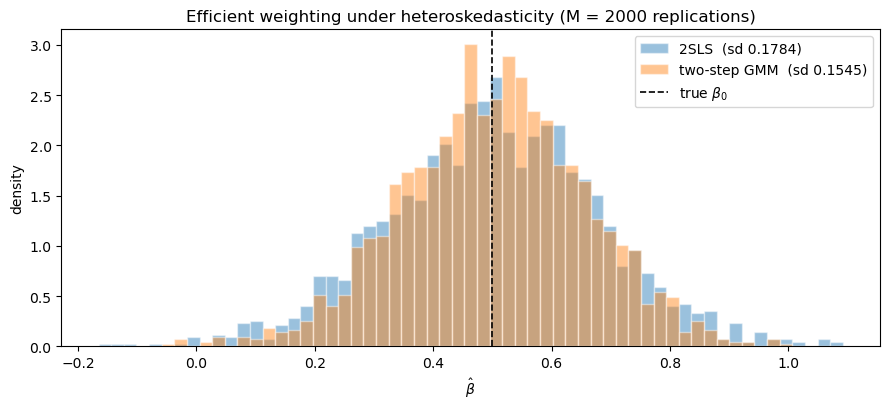

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
bins_g = np.linspace(min(β2sls_m.min(), βgmm_m.min()),
                     max(β2sls_m.max(), βgmm_m.max()), 60)
ax.hist(β2sls_m, bins=bins_g, density=True, alpha=0.45, edgecolor='white',
        label=f'2SLS  (sd {β2sls_m.std():.4f})')
ax.hist(βgmm_m, bins=bins_g, density=True, alpha=0.45, edgecolor='white',
        label=f'two-step GMM  (sd {βgmm_m.std():.4f})')
ax.axvline(β_true, color='k', ls='--', lw=1.2, label=r'true $\beta_0$')
ax.set_xlabel(r'$\hat\beta$')
ax.set_ylabel('density')
ax.set_title(f'Efficient weighting under heteroskedasticity (M = {M} replications)')
ax.legend()
plt.tight_layout()
plt.show()


Under this strongly heteroskedastic DGP, two-step GMM has a standard deviation about $13\%$ smaller than 2SLS, a meaningful efficiency gain. Both estimators are *consistent* for the same parameter, and their Monte Carlo means sit close to $\beta_0$ at this sample size; the difference lies in the sampling spread. (Consistency is the right word here: like IV generally, neither estimator is unbiased in finite samples, see Lecture 10, §1.) When the heteroskedasticity is mild (as in Mroz), the gain is correspondingly small; when it is strong, GMM is unambiguously preferred.

# 7. GMM as a unifying framework

Many estimators we have already met are GMM in disguise. Identifying their moment $g$, weight matrix $W$, and resulting asymptotic variance reveals the structure shared by these methods.

| Estimator | Moment $g_i(\theta)$ | Weight matrix $W$ | $V$ at the efficient choice |
|-----------|---------------------|------------------------|------------------------------|
| OLS | $x_i(y_i - x_i^\top\beta)$ | any (just-identified) | $\sigma^2\bigl(\mathbb{E}[xx^\top]\bigr)^{-1}$ under homosk.; sandwich under heterosk. |
| IV (just-identified) | $z_i(y_i - x_i^\top\beta)$ | any (just-identified) | $\bigl(\mathbb{E}[zx^\top]\bigr)^{-1}\Omega\bigl(\mathbb{E}[xz^\top]\bigr)^{-1}$ |
| 2SLS | $z_i(y_i - x_i^\top\beta)$ | $(Z^\top Z/I)^{-1}$ | efficient under conditional homoskedasticity only |
| Efficient GMM-IV | $z_i(y_i - x_i^\top\beta)$ | $\hat\Omega^{-1}$ | $(G^\top\Omega^{-1}G)^{-1}$ |
| MLE | $s_i(\theta) = \nabla\log f(z_i;\theta)$ | any (just-identified) | $\mathcal{I}(\theta_0)^{-1}$ by the information identity |

The asymptotic theory we developed for OLS (Lecture 4) and again for MLE (Lecture 8), and will develop once more for IV/2SLS (Lecture 10), can now be seen as a *single* result, the GMM master theorem of §2.2, specialized to different moments and weight matrices. The information identity that gave the MLE its $\mathcal{I}^{-1}$ variance and the Eicker–White sandwich that gave OLS its robust variance are two facets of the same object.

# Looking ahead

GMM is a standard method for moment-based estimation. Three extensions are particularly important:

* **Empirical likelihood (EL) and exponential tilting.** When the model imposes a true moment condition, GMM minimizes a particular quadratic form in $\bar g_I$, but other distance metrics give consistent estimators with the same first-order asymptotic distribution and potentially better higher-order properties. EL is a leading alternative; see Imbens (2002).

* **Conditional moment restrictions.** When the model says $\mathbb{E}[u_i\mid w_i] = 0$ (a *conditional* moment) rather than $\mathbb{E}[u_i\,h(w_i)] = 0$ for a specific $h$, an infinite-dimensional family of unconditional moments is available. Choosing efficiently among them is the subject of *optimal instruments* theory (Chamberlain 1987; Newey 1990).

* **Indirect inference and simulated method of moments.** When $\mathbb{E}[g(z;\theta)]$ is not available in closed form but can be simulated from a generative model, GMM extends to settings where the moments are computed by Monte Carlo at each candidate $\theta$. This brings GMM to bear on structural models in IO, labor, and macro.

Each of these extends the moment-based approach without changing its fundamental logic: identify the population moment condition, estimate its sample analog, choose a sensible distance to minimize, and read off the asymptotic distribution from the master theorem above.

The next lecture (**Lecture 10, instrumental variables**) takes the moment condition $\mathbb{E}[z_i\varepsilon_i] = 0$ that supplied every worked example above and asks the question this lecture took for granted: where does a valid $z$ come from, what does it identify when it is only partially credible, and how much of the machinery survives when the instrument is weak.